In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [36]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

In [4]:
bn22bc_dir="./BN22BC"
bn22bc_buckled_dir="./BN22BC_Buckled"
bn33bc_dir="./BN33BC"
bn44bc_dir="./BN44BC"

"./BN44BC"

In [9]:
lattice_vectors = loadlattice("$bn22bc_dir/BN22BC.out")

3-element Vector{Vector{Float64}}:
 [4.95131868528, 0.0, 0.0]
 [-2.47565934264, 4.28796885693, 0.0]
 [0.0, 0.0, 21.16708]

In [13]:
for vector in loadreciprocallattice("$bn22bc_dir/BN22BC.out")
    println(sum(vector.*lattice_vectors[3])/2/pi)
end

Reciprocal Lattice Vectors (in inverse angstrom): 
0.0
0.0
1.0000023384349968


In [19]:
k = normalize_kvector(lattice_vectors, [-0.000240259, 9.27858e-05, 0])

3-element Vector{Float64}:
 -0.00018933054141302702
  0.00015798707347281283
  0.0

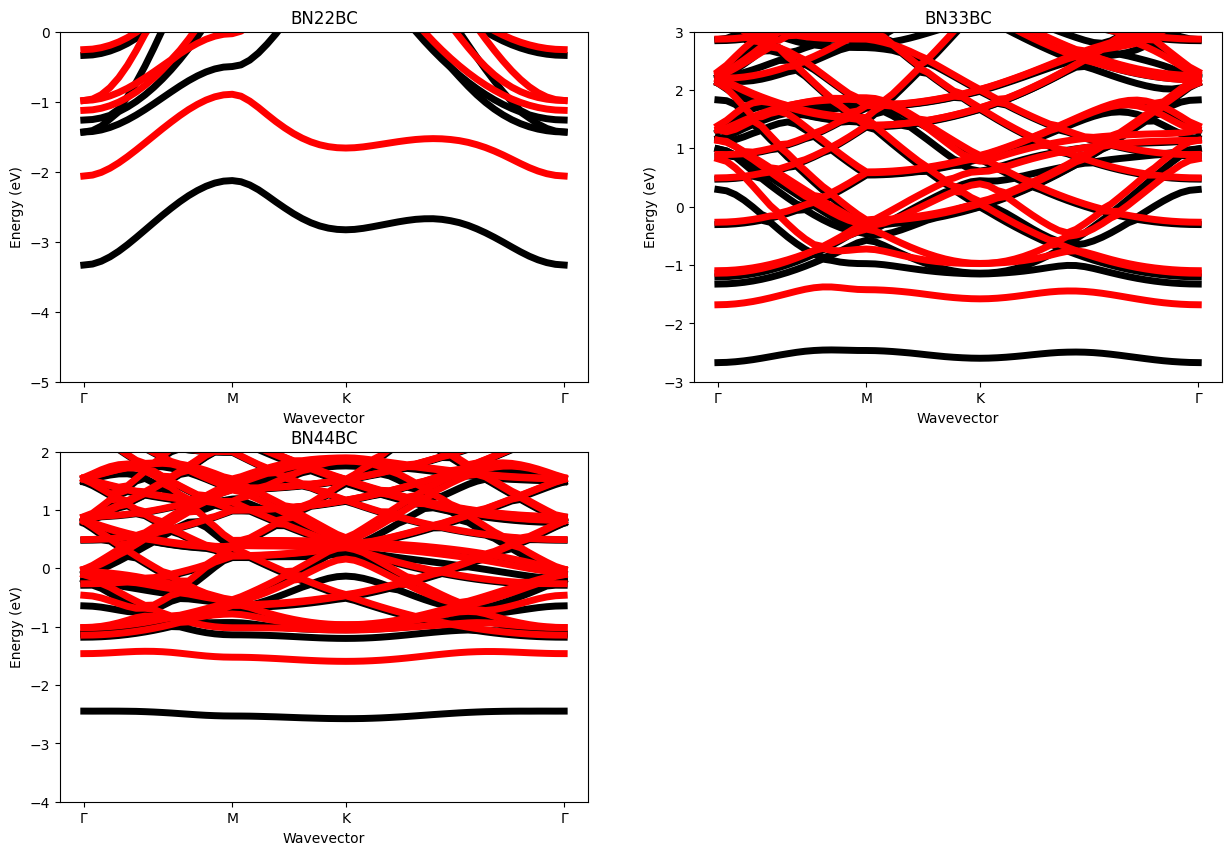

PyObject Text(0.5, 1.0, 'BN44BC')

In [4]:
figure(figsize=(15, 10))
subplot(2, 2, 1)
plot_bands("$bn22bc_dir/BN22BC.bands.eigenvals", spin=2, to_greek=true)
title("BN22BC")
ylim(-5, 0)
subplot(2, 2, 2)
plot_bands("$bn33bc_dir/BN33BC.bands.eigenvals", spin=2, to_greek=true)
title("BN33BC")
ylim(-3, 3)
subplot(2, 2, 3)
plot_bands("$bn44bc_dir/BN44BC.bands.eigenvals", spin=2, to_greek=true)
ylim(-4, 2)
title("BN44BC")

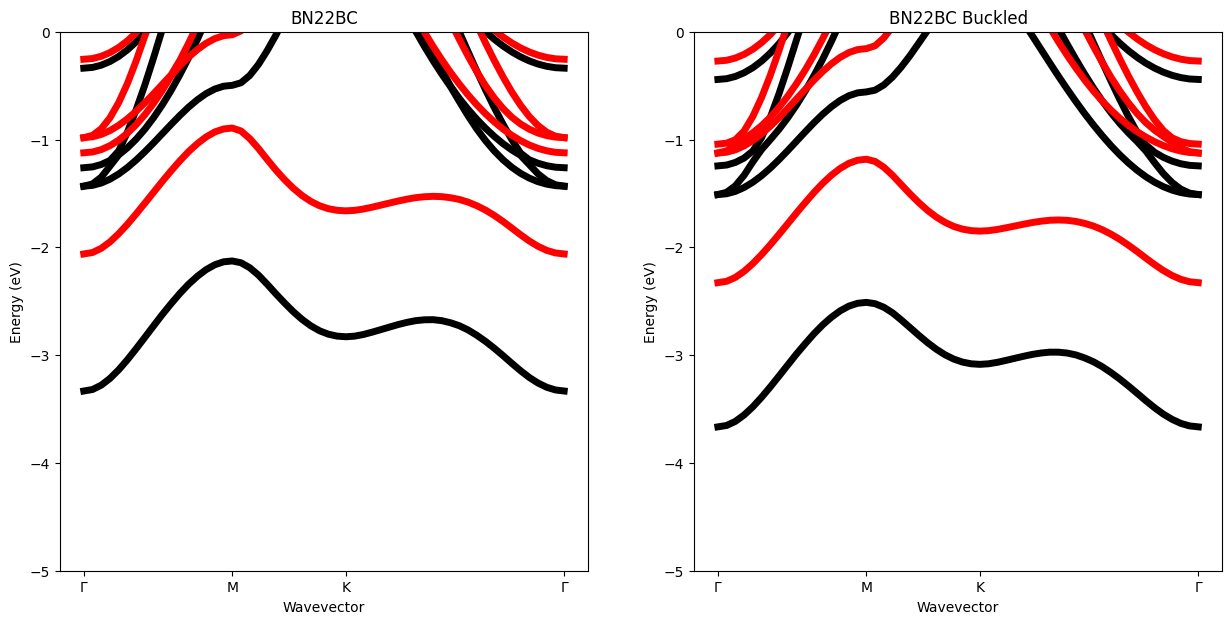

(-5.0, 0.0)

In [84]:
figure(figsize=(15, 7))
subplot(1, 2, 1)
plot_bands("$bn22bc_dir/BN22BC.bands.eigenvals", spin=2, to_greek=true)
title("BN22BC")
ylim(-5, 0)
subplot(1, 2, 2)
plot_bands("$bn22bc_buckled_dir/BN22BC.bands.eigenvals", spin=2, to_greek=true)
title("BN22BC Buckled")
ylim(-5, 0)

In [5]:
Energies22=zeros(100)
Magnetizations22=zeros(100)
for i in 1:100
    Magnetizations22[i] = get_mag("$bn22bc_dir/magnetization/BN22BC-$i.out")
    Energies22[i] = list_energy("$bn22bc_dir/magnetization/BN22BC-$i.out")
end

In [6]:
Energies33=zeros(100)
Magnetizations33=zeros(100)
for i in 1:100
    #println(i)
    try
    Magnetizations33[i] = get_mag("$bn33bc_dir/magnetization/BN33BC-$i.out")
    Energies33[i] = list_energy("$bn33bc_dir/magnetization/BN33BC-$i.out")
    catch
    end
end

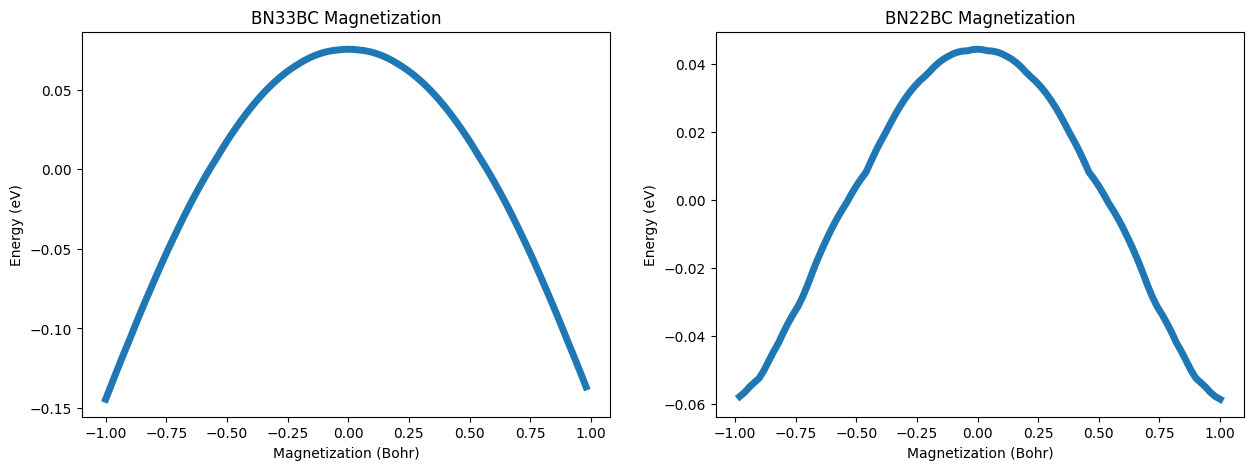

PyObject Text(0.5, 24.0, 'Magnetization (Bohr)')

In [7]:
figure(figsize=(15, 5))
subplot(1, 2, 1)
plot(Magnetizations33, Energies33 .-  mean(Energies33), linewidth=5)
title("BN33BC Magnetization")
ylabel("Energy (eV)")
title("BN33BC Magnetization")
xlabel("Magnetization (Bohr)")
subplot(1, 2, 2)
plot(Magnetizations22, Energies22 .- mean(Energies22), linewidth=5)
ylabel("Energy (eV)")
title("BN22BC Magnetization")
xlabel("Magnetization (Bohr)")

In [72]:
force_matrix, cell_map = phonon_force_matrix("$bn22bc_dir/phonon");
force_matrix_buckled, cell_map_buckled = phonon_force_matrix("$bn22bc_buckled_dir/phonon");

Number of phonon modes is: 24
If this is incorrect, something went wrong somewhere at some point.
Number of phonon modes is: 24
If this is incorrect, something went wrong somewhere at some point.


In [60]:
phonon_bands = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);

In [73]:
phonon_bands_buckled = phonon_dispersionpath(force_matrix_buckled, cell_map_buckled, kpointsfile="bandstruct.kpoints", return_negative=true);

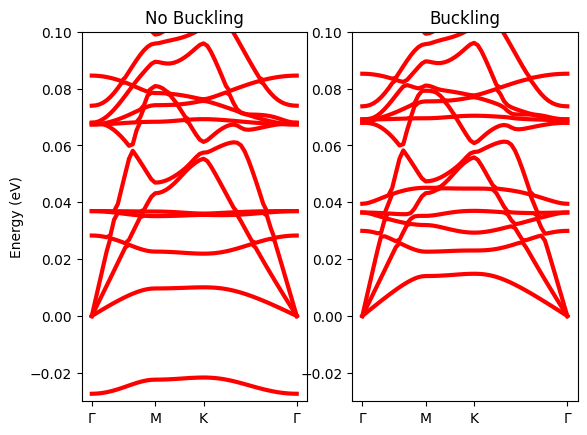

(-0.03, 0.1)

In [78]:
subplot(1, 2, 1)
plot(phonon_bands, linewidth=3, color="red")
label_plots()
ylabel("Energy (eV)")
title("No Buckling")
ylim(-0.03, 0.1)
subplot(1, 2, 2)
plot(phonon_bands_buckled, linewidth=3, color="red")
label_plots()
title("Buckling")
ylim(-0.03, 0.1)

In [43]:
[p[1] for p in phonon_dispersion.(Ref(force_matrix), Ref(cell_map), [q  for q in [k ./ 100 *i for i in 1:100]] , return_negative=true)*eV]

100-element Vector{Float64}:
 -0.0010052070642324227
 -0.0010052070642186113
 -0.0010052070641955984
 -0.0010052070641633857
 -0.0010052070641219622
 -0.0010052070640713358
 -0.0010052070640114948
 -0.0010052070639424602
 -0.0010052070638642135
 -0.0010052070637767622
 -0.0010052070636801026
 -0.0010052070635742445
 -0.0010052070634591758
  ⋮
 -0.001005207027779312
 -0.001005207026955433
 -0.001005207026122351
 -0.0010052070252800633
 -0.0010052070244285663
 -0.0010052070235678767
 -0.0010052070226979671
 -0.0010052070218188615
 -0.001005207020930538
 -0.0010052070200330244
 -0.0010052070191262964
 -0.0010052070182103752

In [55]:
phonon_dispersion(force_matrix, cell_map, [0, 0, 0], return_negative=true)

24-element Vector{Float64}:
 -0.027353091507779658
 -2.7548140271950296e-9
  1.192205469443938e-9
  2.840727159445403e-9
  0.02830012431393632
  0.03689346577838627
  0.036893465778386376
  0.06736950578652433
  0.06736950578652438
  0.06796372752641981
  0.06796372752641998
  0.07396211213039897
  0.08454737262219467
  0.1342849153744948
  0.1456788903194319
  0.14567889031943193
  0.15102265364038214
  0.15530589619537563
  0.15530589619537571
  0.16317930900675218
  0.1631793090067522
  0.16339725915708697
  0.1716007337040448
  0.17160073370404494

In [80]:
abs.(phonon_dispersionmodes(force_matrix_buckled, cell_map_buckled, [0, 0, 0])[2][:, 7])

24-element Vector{Float64}:
 0.00015504930216639438
 0.002802882224382881
 0.9255270925440272
 0.0003495030103355054
 0.004836314109344728
 0.1379024196635248
 0.0031672942674610643
 0.002270892646174503
 0.15038334747894314
 0.00014260674065921732
 0.0012529765033123246
 0.009449834139348386
 0.003552012945569296
 0.0024287089574255606
 0.15143030238869845
 0.0009332577006218294
 0.0003585842907014526
 0.15953067723244793
 0.00014934703490241275
 0.0008190463958557383
 0.16442194736219276
 0.001123795426297939
 0.0005061348118337387
 0.16184073759367903